# Targets generation

In [ ]:
import numpy as np
from src.targets_generation import Gaussian_seq

In [ ]:
N = 500 # number of neurons
T = 10.5 # sequence length (in seconds)
dt = 0.001 # integration step (in seconds)
sigma = np.sqrt(0.3) # width of the gaussian curve
epsilon = 0.05

In [ ]:
gs = Gaussian_seq(T, dt)
targets = gs.target_functions(T, sigma, N, epsilon)

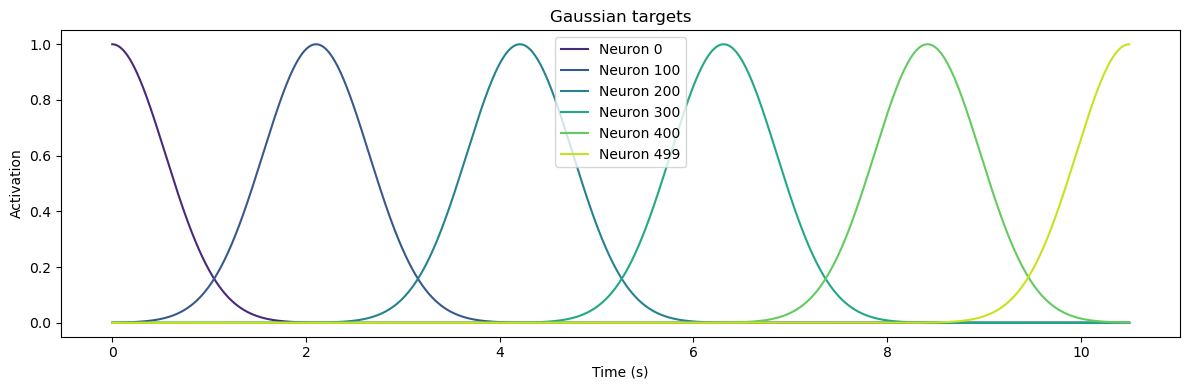

In [ ]:
gs.gaussian_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499])

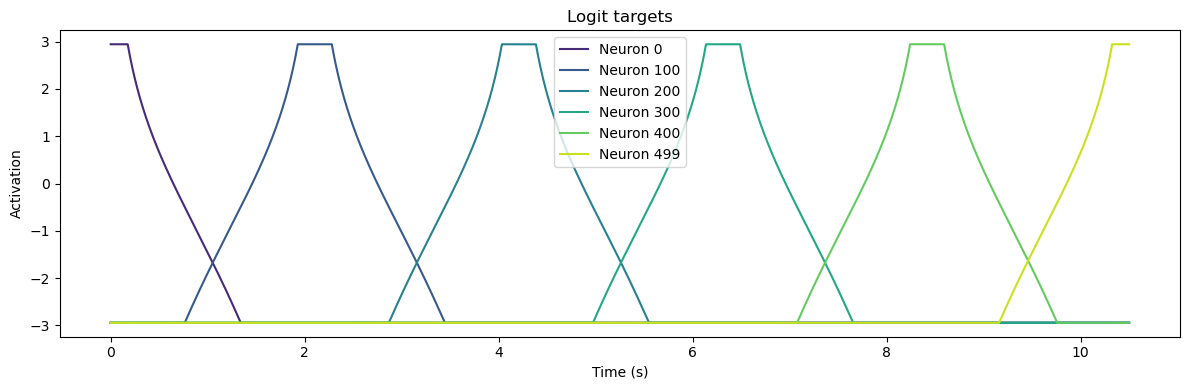

In [ ]:
gs.target_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499], epsilon=epsilon)

# Inputs generation

In [ ]:
from src.inputs_generation import Inputs

In [ ]:
WN_tau = 1  # inputs' correlation time (in seconds)
h0 = 0.15 # inputs' scale

In [ ]:
ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

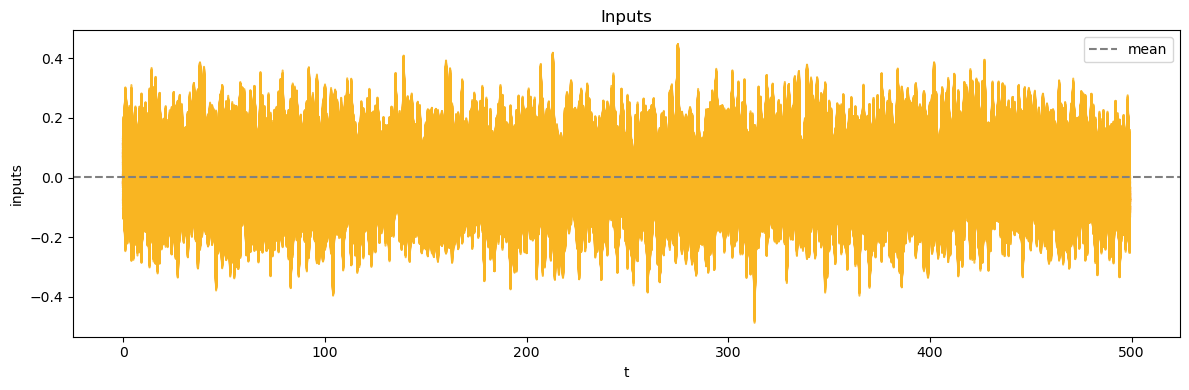

In [9]:
ipt.display_inputs(N, WN_tau, h0)

# Training

In [10]:
from src.training import RNN, PINning

Training parameters, fixed according to Rajan, Harvey & Tank (2016).

In [11]:
p = 0.08 # fraction of plastic synapses in the network
g = 1.5 # chaos parameter in [1.2, 1.5]
tau = 0.01 # membrane time constant (in seconds)
theta = 0 # sigmoid threshold
p0 = 10 # initial P matrix scaling factor: amplitude of 1 to 10 times h0
n_runs = 500 # number of training steps to learn J
n_steps = 50 # number of additionnal steps where J is not modified
cv_threshold = 0.02 # error value at which we deem the model to converge
p_reg = 1e-9 # Ridge regularization parameter

Run 1 | run_error=0.031900 | ||J||=436.24 | Δ||J||=+0.00
Run 2 | run_error=0.079594 | ||J||=472.82 | Δ||J||=+36.58
Run 3 | run_error=0.099355 | ||J||=526.01 | Δ||J||=+53.18
Run 4 | run_error=0.081048 | ||J||=556.77 | Δ||J||=+30.76
Run 5 | run_error=0.059317 | ||J||=580.92 | Δ||J||=+24.14
Run 6 | run_error=0.047985 | ||J||=591.13 | Δ||J||=+10.22
Run 7 | run_error=0.048551 | ||J||=604.07 | Δ||J||=+12.93
Run 8 | run_error=0.043147 | ||J||=613.46 | Δ||J||=+9.40
Run 9 | run_error=0.043117 | ||J||=619.98 | Δ||J||=+6.52
Run 10 | run_error=0.042790 | ||J||=627.07 | Δ||J||=+7.09
Run 11 | run_error=0.040473 | ||J||=631.63 | Δ||J||=+4.56
Run 12 | run_error=0.046804 | ||J||=637.77 | Δ||J||=+6.13
Run 13 | run_error=0.045139 | ||J||=643.52 | Δ||J||=+5.75
Run 14 | run_error=0.041087 | ||J||=647.22 | Δ||J||=+3.71
Run 15 | run_error=0.038616 | ||J||=652.61 | Δ||J||=+5.38
Run 16 | run_error=0.035271 | ||J||=651.08 | Δ||J||=-1.52
Run 17 | run_error=0.048139 | ||J||=654.21 | Δ||J||=+3.13
Run 18 | run_erro

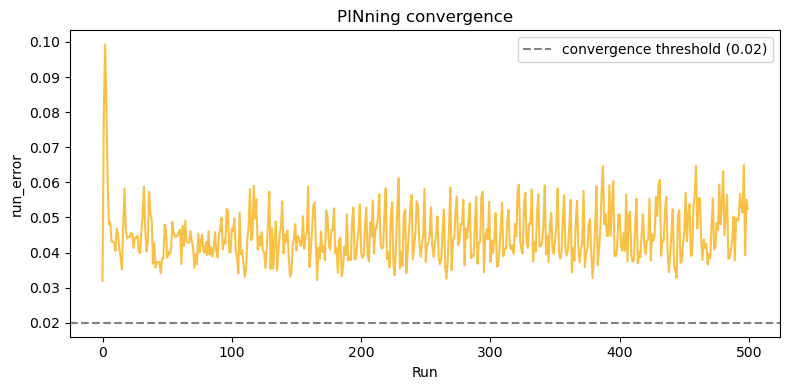

In [12]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True, p_reg=p_reg)
# print(np.linalg.eigvalsh(PINned_model.P).min())
PINned_model.display_cv(errors)

In [13]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)

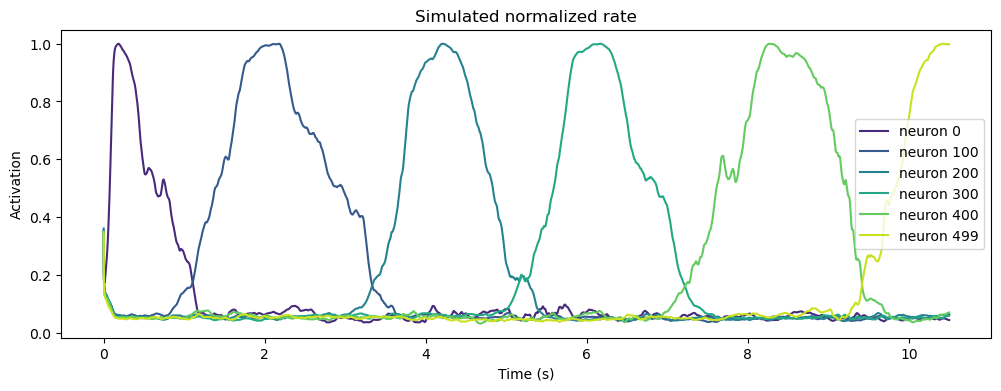

In [14]:
neuron_list = [0, 100, 200, 300, 400, 499]
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

# Evaluation

In [15]:
threshold = 0.95

In [16]:
from src.evaluation import Metrics

In [17]:
from scipy.special import expit
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = gs.t, sigma = sigma, threshold = threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.672105,0.95759,9
1,Article's metrics for p=0.08,1,0.92,10


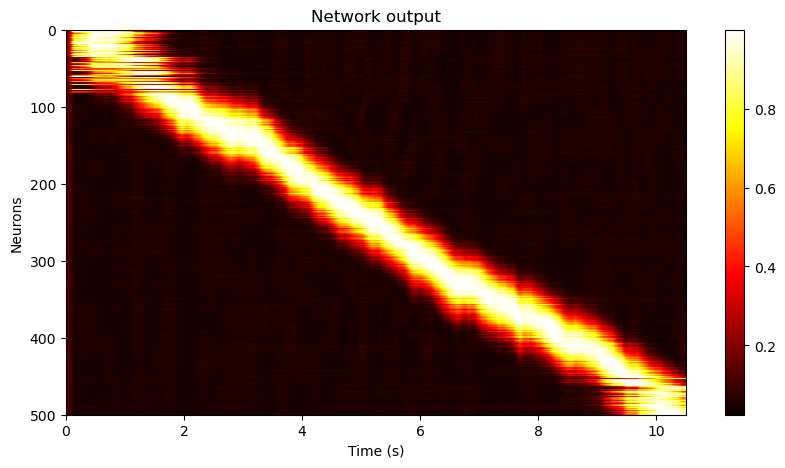

In [18]:
Metrics.network_output(final_rates, T, dt)

# Model logging

In [19]:
from datetime import datetime
model_path = f'model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.npz'

In [20]:
PINned_model.save(model_path)

# Synaptic strength distribution

In [21]:
from src.training import PINning

In [22]:
model, inputs = PINning.load(model_path)

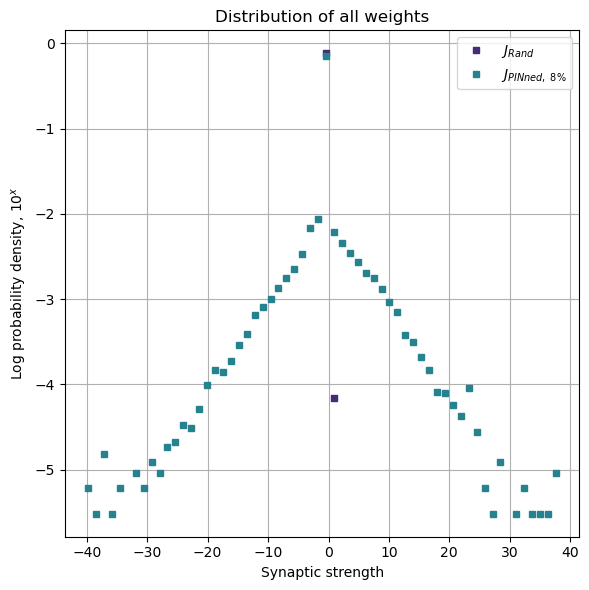

In [23]:
model.display_weight_distribution(value = 'all', bins=60)

# Fine-tuning on positive weigths

In [24]:
import numpy as np
from scipy.special import expit

model, inputs = PINning.load('model_20260706_171109.npz')

targets_rate = expit(model.targets)

dt = model.rnn.dt
T_steps = inputs.shape[1]
t = np.arange(T_steps) * dt    

KeyError: 't is not a file in the archive'

Run 1 | run_error=3.868910 | ||J||=583.55 | Δ||J||=+0.00
Run 2 | run_error=3.435667 | ||J||=602.99 | Δ||J||=+19.45
Run 3 | run_error=3.345458 | ||J||=616.35 | Δ||J||=+13.35
Run 4 | run_error=3.325593 | ||J||=627.29 | Δ||J||=+10.95
Run 5 | run_error=3.322665 | ||J||=638.07 | Δ||J||=+10.77
Run 6 | run_error=3.247133 | ||J||=652.76 | Δ||J||=+14.69
Run 7 | run_error=8.410303 | ||J||=744.90 | Δ||J||=+92.14
Run 8 | run_error=46.339046 | ||J||=1007.78 | Δ||J||=+262.88
Run 9 | run_error=81.303418 | ||J||=1276.35 | Δ||J||=+268.56
Run 10 | run_error=271.926394 | ||J||=1664.13 | Δ||J||=+387.78
Run 11 | run_error=586.631572 | ||J||=2447.85 | Δ||J||=+783.72
Run 12 | run_error=2556.194820 | ||J||=3686.40 | Δ||J||=+1238.55
Run 13 | run_error=4047.382671 | ||J||=4695.12 | Δ||J||=+1008.73
Run 14 | run_error=9297.090889 | ||J||=7809.31 | Δ||J||=+3114.18
Run 15 | run_error=67444.584459 | ||J||=13723.09 | Δ||J||=+5913.79
Run 16 | run_error=156134.459583 | ||J||=16368.68 | Δ||J||=+2645.59
Run 17 | run_erro

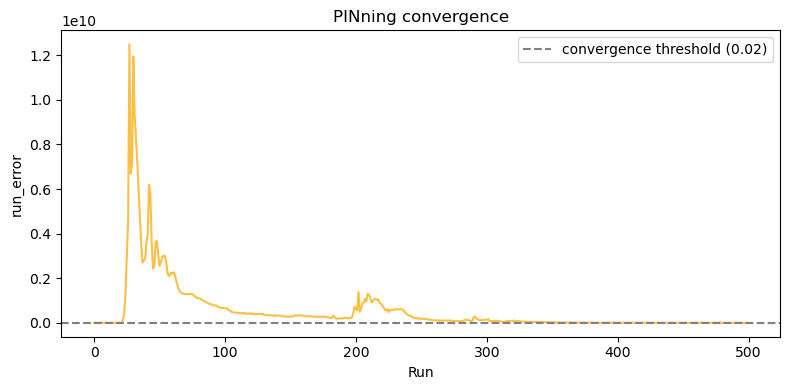

In [ ]:
constr_errors, constr_j_norms = model.train_constrained(inputs, n_runs, cv_threshold, DEBUG= True, p_reg=p_reg)
model.display_cv(constr_errors)

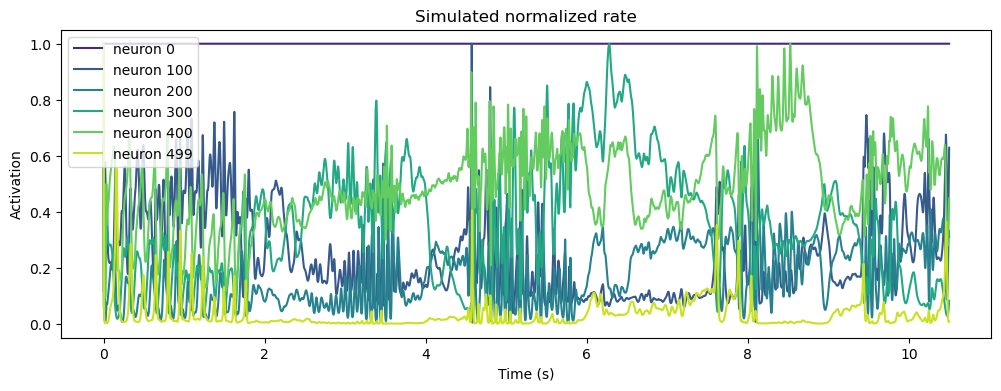

NameError: name 'Metrics' is not defined

In [ ]:
final_constr_rates = model.simulate(inputs, n_steps)
model.display_simulation(T, dt, final_constr_rates, neuron_list=[0, 100, 200, 300, 400, 499])
Metrics.general_evaluation(rates=final_constr_rates, targets=targets_rate, t=t, sigma=sigma, threshold=threshold)

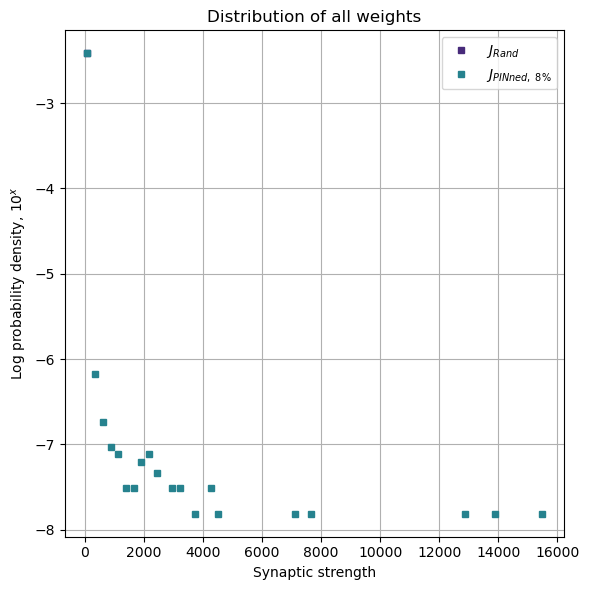

In [ ]:
model.display_weight_distribution(value='all')